# Classificação do Estado Operacional de Sistemas Espaciais com Keras

Objetivos:
- Preparar os dados;
- Treinar diferentes redes neurais;
- Comparar resultados;
- Analisar accuracy, loss, estabilidade e overfitting.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from tensorflow.keras.optimizers import Adam


## 1. Carregamento dos Dados

In [3]:
train = pd.read_csv('orbital_train.csv')
test = pd.read_csv('orbital_test.csv')

print('Treino:', train.shape)
print('Teste:', test.shape)

train.head()


Treino: (16504, 26)
Teste: (4127, 26)


,op_setting_1,op_setting_2,op_setting_3,sensor_1,sensor_2,sensor_3,sensor_4,sensor_5,sensor_6,sensor_7,...,sensor_14,sensor_15,sensor_16,sensor_17,sensor_18,sensor_19,sensor_20,sensor_21,RUL,target
0,-0.0068,-0.0001,100.0,518.67,643.20,1592.85,1414.54,14.62,21.61,552.84,...,8163.61,8.4116,0.03,395,2388,100.0,38.90,23.2545,46,2
1,0.0007,0.0004,100.0,518.67,642.49,1581.95,1394.86,14.62,21.61,554.71,...,8138.39,8.3967,0.03,392,2388,100.0,39.18,23.3452,166,0
2,0.0003,-0.0004,100.0,518.67,641.90,1582.73,1395.11,14.62,21.61,553.73,...,8148.14,8.3630,0.03,393,2388,100.0,39.04,23.3386,164,0
3,-0.0009,-0.0001,100.0,518.67,643.61,1602.13,1424.76,14.62,21.61,551.73,...,8220.91,8.4963,0.03,396,2388,100.0,38.41,23.0797,2,2
4,-0.0006,-0.0002,100.0,518.67,642.92,1589.88,1403.38,14.62,21.61,553.66,...,8135.20,8.4359,0.03,392,2388,100.0,38.76,23.2917,130,0


## 2. Preparação dos Dados

In [4]:
X_train = train.drop('target', axis=1)
y_train = train['target']

X_test = test.drop('target', axis=1)
y_test = test['target']

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

y_train_cat = to_categorical(y_train, num_classes=3)
y_test_cat = to_categorical(y_test, num_classes=3)

print(X_train.shape)
print(y_train_cat.shape)


(16504, 25)
(16504, 3)


## 3. Modelo 1 - Rede Simples

In [5]:
model1 = Sequential([
    Dense(32, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(3, activation='softmax')
])

model1.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history1 = model1.fit(
    X_train,
    y_train_cat,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1
)


/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.7938 - loss: 0.5208 - val_accuracy: 0.8806 - val_loss: 0.3323
Epoch 2/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9061 - loss: 0.2739 - val_accuracy: 0.9218 - val_loss: 0.2291
Epoch 3/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9362 - loss: 0.1963 - val_accuracy: 0.9488 - val_loss: 0.1686
Epoch 4/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9549 - loss: 0.1474 - val_accuracy: 0.9652 - val_loss: 0.1287
Epoch 5/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9679 - loss: 0.1158 - val_accuracy: 0.9706 - val_loss: 0.1052
Epoch 6/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9751 - loss: 0.0952 - val_accuracy: 0.9800 - val_loss: 0.0866
Epoch 7/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9799 - loss: 0.0814 - val_accuracy: 0.9800 - val_loss: 0.0771
Epoch 8/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9825 - loss: 0.0718 - val_accuracy: 0.

## 4. Modelo 2 - Rede Mais Profunda

In [6]:
model2 = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dense(32, activation='relu'),
    Dense(16, activation='relu'),
    Dense(3, activation='softmax')
])

model2.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model2.fit(
    X_train,
    y_train_cat,
    validation_split=0.2,
    epochs=30,
    batch_size=32,
    verbose=1
)


Epoch 1/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.8577 - loss: 0.3496 - val_accuracy: 0.9361 - val_loss: 0.1645
Epoch 2/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9505 - loss: 0.1218 - val_accuracy: 0.9697 - val_loss: 0.0896
Epoch 3/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9696 - loss: 0.0780 - val_accuracy: 0.9767 - val_loss: 0.0640
Epoch 4/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.9744 - loss: 0.0637 - val_accuracy: 0.9785 - val_loss: 0.0538
Epoch 5/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9776 - loss: 0.0550 - val_accuracy: 0.9758 - val_loss: 0.0565
Epoch 6/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9816 - loss: 0.0453 - val_accuracy: 0.9688 - val_loss: 0.0804
Epoch 7/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.9814 - loss: 0.0442 - val_accuracy: 0.9718 - val_loss: 0.0626
Epoch 8/30
413/413 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9826 - loss: 0.0405 - val_accuracy: 0.

## 5. Modelo 3 - Rede com Regularização (Dropout)

In [7]:
model3 = Sequential([
    Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    Dropout(0.3),
    Dense(32, activation='relu'),
    Dropout(0.3),
    Dense(3, activation='softmax')
])

model3.compile(
    optimizer='adam',
    loss='categorical_crossentropy',
    metrics=['accuracy']
)

history3 = model3.fit(
    X_train,
    y_train_cat,
    validation_split=0.2,
    epochs=30,
    batch_size=64,
    verbose=1
)


Epoch 1/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 2s 4ms/step - accuracy: 0.6804 - loss: 0.6689 - val_accuracy: 0.8500 - val_loss: 0.3591
Epoch 2/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8609 - loss: 0.3388 - val_accuracy: 0.9112 - val_loss: 0.2164
Epoch 3/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - accuracy: 0.8984 - loss: 0.2421 - val_accuracy: 0.9318 - val_loss: 0.1599
Epoch 4/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9215 - loss: 0.1977 - val_accuracy: 0.9546 - val_loss: 0.1244
Epoch 5/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.9295 - loss: 0.1695 - val_accuracy: 0.9676 - val_loss: 0.0959
Epoch 6/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - accuracy: 0.9431 - loss: 0.1440 - val_accuracy: 0.9752 - val_loss: 0.0787
Epoch 7/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9471 - loss: 0.1280 - val_accuracy: 0.9791 - val_loss: 0.0697
Epoch 8/30
207/207 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.9533 - loss: 0.1152 - val_accuracy: 0.

## 6. Comparação das Curvas de Accuracy

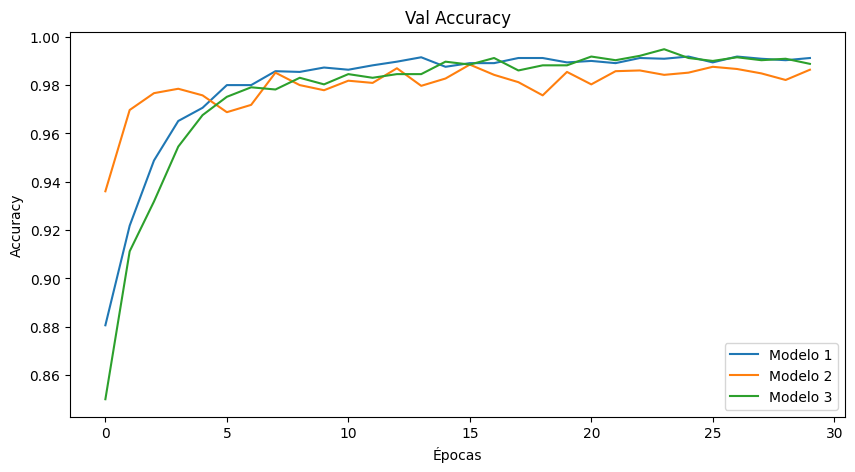

In [8]:
plt.figure(figsize=(10,5))

plt.plot(history1.history['val_accuracy'], label='Modelo 1')
plt.plot(history2.history['val_accuracy'], label='Modelo 2')
plt.plot(history3.history['val_accuracy'], label='Modelo 3')

plt.title('Val Accuracy')
plt.xlabel('Épocas')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


## 7. Avaliação Final

In [9]:
models = {
    'Modelo 1': model1,
    'Modelo 2': model2,
    'Modelo 3': model3
}

for nome, modelo in models.items():
    loss, acc = modelo.evaluate(X_test, y_test_cat, verbose=0)
    print(f'{nome} -> Accuracy: {acc:.4f} | Loss: {loss:.4f}')


Modelo 1 -> Accuracy: 0.9920 | Loss: 0.0259
Modelo 2 -> Accuracy: 0.9852 | Loss: 0.0368
Modelo 3 -> Accuracy: 0.9889 | Loss: 0.0240


## 8. Discussão dos Resultados

Analise:
- Qual modelo apresentou maior accuracy;
- Qual apresentou menor loss;
- Evidências de overfitting;
- Impacto do número de camadas;
- Impacto do Dropout;
- Estabilidade do treinamento;
- Diferenças entre os modelos.
